In [1]:
import numpy as np
import pandas as pd
from decimal import Decimal
import re

In [2]:
coinbase_df = pd.read_csv("../data/coinbase_addresses_full.csv")
coinbase_df

,block_number,block_timestamp,real_outputs
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...
...,...,...,...
810904,762082,2022-11-07 04:51:06+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...
810905,761961,2022-11-06 09:03:17+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...
810906,763253,2022-11-15 08:27:13+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...
810907,762893,2022-11-12 15:41:42+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...


In [3]:
with pd.option_context('display.max_colwidth', None):
    # coinbase with 1 payout address only
    print(coinbase_df["real_outputs"].head())

    # coinbase payout with more than 1 address
    # we can see the dictionaries of an address with their corresponding payment gets separated by a \n character
    print(coinbase_df["real_outputs"].iloc[122:129])


0    [{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX', 'script_type': 'pubkeyhash', 'value': Decimal('627599947.000000000')}]
1    [{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX', 'script_type': 'pubkeyhash', 'value': Decimal('625618704.000000000')}]
2    [{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX', 'script_type': 'pubkeyhash', 'value': Decimal('645109778.000000000')}]
3    [{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ', 'script_type': 'scripthash', 'value': Decimal('643550458.000000000')}]
4    [{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd', 'script_type': 'scripthash', 'value': Decimal('628673349.000000000')}]
Name: real_outputs, dtype: str
122    [{'address': '18xtwHorWnJnqSPnWbzrqVmWRCuJ7cxYWT', 'script_type': 'pubkeyhash', 'value': Decimal('232205.000000000')}\n {'address': '16xrhbRacoX2cfCnCgrwFp1ZsE77NU3VUN', 'script_type': 'pubkeyhash', 'value': Decimal('238002.000000000')}\n {'address': '1QTk75pBdBc6qvnsy5cq3wp8rF51nqDzW', 'script_type': 'pubkeyhash', 'value': D

In [4]:
# Formatting the real_outputs column data with regex and decimal conversion

# This regex restores the comma between entries before we hand the string to eval().
def parse_outputs(s):
    fixed = re.sub(r"\}\s*\n\s*\{", "}, {", s)
    return eval(fixed, {"Decimal": Decimal, "__builtins__": {}})

coinbase_df["real_outputs_parsed"] = coinbase_df["real_outputs"].apply(parse_outputs)
coinbase_df["n_addresses"] = coinbase_df["real_outputs_parsed"].apply(len)

In [5]:
coinbase_df

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,1
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,1
...,...,...,...,...,...
810904,762082,2022-11-07 04:51:06+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1
810905,761961,2022-11-06 09:03:17+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1
810906,763253,2022-11-15 08:27:13+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1
810907,762893,2022-11-12 15:41:42+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1


In [6]:
# coinbase payout with more than 1 payout address
# we can see the original dictionaries of an address with their corresponding payment gets separated by a \n character
# we replace the \n with a comma
with pd.option_context('display.max_colwidth', None):
    print(coinbase_df[coinbase_df["n_addresses"] > 1]["real_outputs"].head())
    print(coinbase_df[coinbase_df["n_addresses"] > 1]["real_outputs_parsed"].head())

24                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

## get_primary_miner with multiple miners returned

In [7]:
def get_primary_miner(coinbase_payouts):
    if coinbase_payouts == []:
        return []
    
    highest_payout = max(coinbase_payouts, key=lambda x: x["value"])
    
    highest_payouts = []
    for payout in coinbase_payouts:
        if payout["value"] == highest_payout["value"]:
            highest_payouts.append(payout)
    
    return highest_payouts

In [8]:
# multi address blocks test
# block: 224245, 419094, 526591, 501726, 759475
test_blocks_df = coinbase_df[coinbase_df["block_number"].isin([224245, 419094, 526591, 501726, 759475])].copy()
test_blocks_df

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses
24,419094,2016-07-03 09:14:39+00:00,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,2
103,224245,2013-03-04 15:50:11+00:00,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,1
185312,526591,2018-06-08 14:52:50+00:00,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,1
557777,501726,2017-12-30 12:55:20+00:00,[],[],0
749037,759475,2022-10-20 05:58:43+00:00,[],[],0


In [9]:
test_blocks_df["highest_payout_address"] = test_blocks_df["real_outputs_parsed"].apply(get_primary_miner)
with pd.option_context('display.max_colwidth', None):
    print(test_blocks_df)

        block_number            block_timestamp  \
24            419094  2016-07-03 09:14:39+00:00   
103           224245  2013-03-04 15:50:11+00:00   
185312        526591  2018-06-08 14:52:50+00:00   
557777        501726  2017-12-30 12:55:20+00:00   
749037        759475  2022-10-20 05:58:43+00:00   

                                                                                                                                                                                                                                               real_outputs  \
24      [{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63PeVg', 'script_type': 'pubkeyhash', 'value': Decimal('2509616020.000000000')}\n {'address': '19ZKM6JFvCiBQbqqHPzRDLGHpN6wkQnXDs', 'script_type': 'pubkeyhash', 'value': Decimal('22791669.000000000')}]   
103                                                                                                                              [{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukdNz', 'sc

## get_primary_miner with only 1 miner returned max

### Return a tuple: (address, tie_count)

In [10]:
def get_primary_miner(coinbase_payouts):
    if coinbase_payouts == []:
        return (None, 0)
    
    highest_payout = max(coinbase_payouts, key=lambda x: x["value"])
    
    highest_payouts = []
    for payout in coinbase_payouts:
        if payout["value"] == highest_payout["value"]:
            highest_payouts.append(payout)
    
    return (highest_payouts[0]["address"], len(highest_payouts))

In [11]:
# multi address blocks test
# block: 224245, 419094, 526591, 501726, 759475
test_blocks_df = coinbase_df[coinbase_df["block_number"].isin([224245, 419094, 526591, 501726, 759475])].copy()
test_blocks_df

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses
24,419094,2016-07-03 09:14:39+00:00,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,2
103,224245,2013-03-04 15:50:11+00:00,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,1
185312,526591,2018-06-08 14:52:50+00:00,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,1
557777,501726,2017-12-30 12:55:20+00:00,[],[],0
749037,759475,2022-10-20 05:58:43+00:00,[],[],0


In [12]:
test_blocks_df["primary_miner_result"] = test_blocks_df["real_outputs_parsed"].apply(get_primary_miner)
with pd.option_context('display.max_colwidth', None):
    print(test_blocks_df)

        block_number            block_timestamp  \
24            419094  2016-07-03 09:14:39+00:00   
103           224245  2013-03-04 15:50:11+00:00   
185312        526591  2018-06-08 14:52:50+00:00   
557777        501726  2017-12-30 12:55:20+00:00   
749037        759475  2022-10-20 05:58:43+00:00   

                                                                                                                                                                                                                                               real_outputs  \
24      [{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63PeVg', 'script_type': 'pubkeyhash', 'value': Decimal('2509616020.000000000')}\n {'address': '19ZKM6JFvCiBQbqqHPzRDLGHpN6wkQnXDs', 'script_type': 'pubkeyhash', 'value': Decimal('22791669.000000000')}]   
103                                                                                                                              [{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukdNz', 'sc

### return 2 columns: primary_miner_address, tie_count

In [13]:
test_blocks_df["primary_miner_address"] = test_blocks_df["primary_miner_result"].str[0]
test_blocks_df["primary_miner_ties"] = test_blocks_df["primary_miner_result"].str[1]
print(test_blocks_df["primary_miner_address"])
print(test_blocks_df["primary_miner_ties"])
test_blocks_df

24        13pucx6gHP2vyBLc88QfcGivjkhK63PeVg
103       19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukdNz
185312    1C1mCxRukix1KfegAY5zQQJV7samAciZpv
557777                                  None
749037                                  None
Name: primary_miner_address, dtype: object
24        1
103       1
185312    1
557777    0
749037    0
Name: primary_miner_ties, dtype: int64


,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
24,419094,2016-07-03 09:14:39+00:00,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,[{'address': '13pucx6gHP2vyBLc88QfcGivjkhK63Pe...,2,"(13pucx6gHP2vyBLc88QfcGivjkhK63PeVg, 1)",13pucx6gHP2vyBLc88QfcGivjkhK63PeVg,1
103,224245,2013-03-04 15:50:11+00:00,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,[{'address': '19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukd...,1,"(19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukdNz, 1)",19fbcmiSmxHGjyBDG2on5Qgfnvxs8ukdNz,1
185312,526591,2018-06-08 14:52:50+00:00,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,[{'address': '1C1mCxRukix1KfegAY5zQQJV7samAciZ...,1,"(1C1mCxRukix1KfegAY5zQQJV7samAciZpv, 1)",1C1mCxRukix1KfegAY5zQQJV7samAciZpv,1
557777,501726,2017-12-30 12:55:20+00:00,[],[],0,"(None, 0)",None,0
749037,759475,2022-10-20 05:58:43+00:00,[],[],0,"(None, 0)",None,0


### Run on 50k rows to test execution time

In [14]:
test_blocks_df_50k = coinbase_df.head(50000).copy()
test_blocks_df_50k["primary_miner_result"] = test_blocks_df_50k["real_outputs_parsed"].apply(get_primary_miner)
test_blocks_df_50k["primary_miner_address"] = test_blocks_df_50k["primary_miner_result"].str[0]
test_blocks_df_50k["primary_miner_ties"] = test_blocks_df_50k["primary_miner_result"].str[1]
test_blocks_df_50k

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,1,"(3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ, 1)",3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ,1
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,1,"(3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd, 1)",3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd,1
...,...,...,...,...,...,...,...,...
49995,358568,2015-05-29 18:18:04+00:00,[{'address': '1BngUovh1zRkLA7aUd98649cFh2scQ6T...,[{'address': '1BngUovh1zRkLA7aUd98649cFh2scQ6T...,135,"(1KH2MiL1wFJ39ewHtNU9GeSaDc9oUjmaMr, 1)",1KH2MiL1wFJ39ewHtNU9GeSaDc9oUjmaMr,1
49996,357309,2015-05-20 19:14:04+00:00,[{'address': '1Te2mYsjyLVemxd3it17G8RPY6E367Hc...,[{'address': '1Te2mYsjyLVemxd3it17G8RPY6E367Hc...,1,"(1Te2mYsjyLVemxd3it17G8RPY6E367HcD, 1)",1Te2mYsjyLVemxd3it17G8RPY6E367HcD,1
49997,358450,2015-05-29 00:58:40+00:00,[{'address': '1FeDtFhARLxjKUPPkQqEBL78tisenc9z...,[{'address': '1FeDtFhARLxjKUPPkQqEBL78tisenc9z...,1,"(1FeDtFhARLxjKUPPkQqEBL78tisenc9znS, 1)",1FeDtFhARLxjKUPPkQqEBL78tisenc9znS,1
49998,354717,2015-05-03 00:54:44+00:00,[{'address': '1FeDtFhARLxjKUPPkQqEBL78tisenc9z...,[{'address': '1FeDtFhARLxjKUPPkQqEBL78tisenc9z...,1,"(1FeDtFhARLxjKUPPkQqEBL78tisenc9znS, 1)",1FeDtFhARLxjKUPPkQqEBL78tisenc9znS,1


In [15]:
test_blocks_df_50k[test_blocks_df_50k['primary_miner_ties'] > 1].sort_values("primary_miner_ties", ascending=False).head(20)

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
8015,419346,2016-07-05 02:07:34+00:00,[{'address': '1DeL5jUwcQPBBSxxtgftuH8d57F4JgaS...,[{'address': '1DeL5jUwcQPBBSxxtgftuH8d57F4JgaS...,26,"(1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno, 25)",1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno,25
20269,419277,2016-07-04 14:55:01+00:00,[{'address': '1CY5dWjAMD8vDMpx5xgsRVZmhEVFLsZf...,[{'address': '1CY5dWjAMD8vDMpx5xgsRVZmhEVFLsZf...,26,"(1CY5dWjAMD8vDMpx5xgsRVZmhEVFLsZfin, 25)",1CY5dWjAMD8vDMpx5xgsRVZmhEVFLsZfin,25
43326,418902,2016-07-02 02:56:38+00:00,[{'address': '1CMRT7iQ9yJGhUQcXuXpPaVS7drQ29CT...,[{'address': '1CMRT7iQ9yJGhUQcXuXpPaVS7drQ29CT...,26,"(1CMRT7iQ9yJGhUQcXuXpPaVS7drQ29CTTi, 25)",1CMRT7iQ9yJGhUQcXuXpPaVS7drQ29CTTi,25
43369,419267,2016-07-04 13:21:57+00:00,[{'address': '1CVUA6vG9aP1zHp3zAnbLHT7LjbUTEiq...,[{'address': '1CVUA6vG9aP1zHp3zAnbLHT7LjbUTEiq...,26,"(1CVUA6vG9aP1zHp3zAnbLHT7LjbUTEiqW9, 25)",1CVUA6vG9aP1zHp3zAnbLHT7LjbUTEiqW9,25
31981,419310,2016-07-04 19:29:10+00:00,[{'address': '1D8zjWf9D43MGVSkicNhBRzKVtnrKeJG...,[{'address': '1D8zjWf9D43MGVSkicNhBRzKVtnrKeJG...,26,"(1D8zjWf9D43MGVSkicNhBRzKVtnrKeJGB5, 25)",1D8zjWf9D43MGVSkicNhBRzKVtnrKeJGB5,25
49869,419327,2016-07-04 23:06:15+00:00,[{'address': '1DcpEqssqoazm8Kutgn4UrAEfYWbajks...,[{'address': '1DcpEqssqoazm8Kutgn4UrAEfYWbajks...,26,"(1DcpEqssqoazm8Kutgn4UrAEfYWbajksaZ, 25)",1DcpEqssqoazm8Kutgn4UrAEfYWbajksaZ,25
46336,418922,2016-07-02 06:39:31+00:00,[{'address': '1CRrqHW2HHoCs7FePfmVnbrYSYu1tQSh...,[{'address': '1CRrqHW2HHoCs7FePfmVnbrYSYu1tQSh...,26,"(1CRrqHW2HHoCs7FePfmVnbrYSYu1tQShwH, 25)",1CRrqHW2HHoCs7FePfmVnbrYSYu1tQShwH,25
22245,419413,2016-07-05 16:16:11+00:00,[{'address': '1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmL...,[{'address': '1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmL...,26,"(1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmLBp, 25)",1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmLBp,25
18534,419308,2016-07-04 19:12:43+00:00,[{'address': '1D54769F3yPqCd7DpENvkYbSM3Ao726V...,[{'address': '1D54769F3yPqCd7DpENvkYbSM3Ao726V...,26,"(1D54769F3yPqCd7DpENvkYbSM3Ao726V1S, 25)",1D54769F3yPqCd7DpENvkYbSM3Ao726V1S,25
15575,419395,2016-07-05 12:18:33+00:00,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,26,"(1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C, 25)",1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C,25


## Convert block_timestamp to datetime type

In [16]:
coinbase_df['block_timestamp'] = pd.to_datetime(coinbase_df['block_timestamp'])
coinbase_df['block_timestamp'].describe()

count                              810909
mean     2016-05-13 12:52:27.924965+00:00
min             2009-01-03 18:15:05+00:00
25%             2012-10-10 22:19:35+00:00
50%             2016-04-02 20:55:40+00:00
75%             2019-12-15 06:03:40+00:00
max             2023-10-06 13:37:21+00:00
Name: block_timestamp, dtype: object

# Running get_primary_miner() on the full dataset

In [17]:
coinbase_df['primary_miner_result'] = coinbase_df['real_outputs_parsed'].apply(get_primary_miner)
coinbase_df['primary_miner_address'] = coinbase_df['primary_miner_result'].str[0]
coinbase_df['primary_miner_ties'] = coinbase_df['primary_miner_result'].str[1]
coinbase_df

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,1,"(3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ, 1)",3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ,1
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,1,"(3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd, 1)",3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd,1
...,...,...,...,...,...,...,...,...
810904,762082,2022-11-07 04:51:06+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810905,761961,2022-11-06 09:03:17+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810906,763253,2022-11-15 08:27:13+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810907,762893,2022-11-12 15:41:42+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1


In [18]:
coinbase_df.sort_values('primary_miner_ties', ascending=False)

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
8015,419346,2016-07-05 02:07:34+00:00,[{'address': '1DeL5jUwcQPBBSxxtgftuH8d57F4JgaS...,[{'address': '1DeL5jUwcQPBBSxxtgftuH8d57F4JgaS...,26,"(1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno, 25)",1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno,25
144395,393816,2016-01-18 05:24:49+00:00,[{'address': '1FYyZwqYd8NRdAJNNnZ2HbDprsjfg9Xf...,[{'address': '1FYyZwqYd8NRdAJNNnZ2HbDprsjfg9Xf...,25,"(1FYyZwqYd8NRdAJNNnZ2HbDprsjfg9XfrL, 25)",1FYyZwqYd8NRdAJNNnZ2HbDprsjfg9XfrL,25
15430,419416,2016-07-05 16:47:35+00:00,[{'address': '1DmRCSTeL8utyMMyZ6oWLju61wsbgy7U...,[{'address': '1DmRCSTeL8utyMMyZ6oWLju61wsbgy7U...,26,"(1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ, 25)",1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ,25
737725,418520,2016-06-29 17:25:10+00:00,[{'address': '1CEwuqSwwUvEYnR1YSjGiijfJTzHqXyq...,[{'address': '1CEwuqSwwUvEYnR1YSjGiijfJTzHqXyq...,26,"(1CEwuqSwwUvEYnR1YSjGiijfJTzHqXyq3p, 25)",1CEwuqSwwUvEYnR1YSjGiijfJTzHqXyq3p,25
15575,419395,2016-07-05 12:18:33+00:00,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,26,"(1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C, 25)",1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C,25
...,...,...,...,...,...,...,...,...
810892,762802,2022-11-12 03:02:22+00:00,[{'address': '1KFHE7w8BhaENAswwryaoccDb6qcT6Db...,[{'address': '1KFHE7w8BhaENAswwryaoccDb6qcT6Db...,1,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1
11,755956,2022-09-27 20:26:16+00:00,[{'address': '1KFHE7w8BhaENAswwryaoccDb6qcT6Db...,[{'address': '1KFHE7w8BhaENAswwryaoccDb6qcT6Db...,1,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1
28,503636,2018-01-11 06:48:41+00:00,[{'address': '13hQVEstgo4iPQZv9C7VELnLWF7UWtF4...,[{'address': '13hQVEstgo4iPQZv9C7VELnLWF7UWtF4...,1,"(13hQVEstgo4iPQZv9C7VELnLWF7UWtF4Q3, 1)",13hQVEstgo4iPQZv9C7VELnLWF7UWtF4Q3,1
749037,759475,2022-10-20 05:58:43+00:00,[],[],0,"(None, 0)",None,0


In [19]:
(coinbase_df['primary_miner_ties'] > 1).sum()

np.int64(487)

### Analyze primary miner ties

In [20]:
tied_df = coinbase_df[coinbase_df['primary_miner_ties'] > 1]
print(tied_df.shape)
print()
print(tied_df['primary_miner_ties'].value_counts())
print()
print(tied_df.describe())

(487, 8)

primary_miner_ties
4     319
5     101
25     65
2       2
Name: count, dtype: int64

        block_number  n_addresses  primary_miner_ties
count     487.000000   487.000000          487.000000
mean   298091.642710     8.498973            7.002053
std     85860.274977    13.152458            7.083424
min    222377.000000     2.000000            2.000000
25%    228000.000000     5.000000            4.000000
50%    245125.000000     5.000000            4.000000
75%    415963.500000     6.000000            5.000000
max    419452.000000   253.000000           25.000000


In [21]:
tied_df.sort_values('block_number')

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
342414,222377,2013-02-21 14:06:24+00:00,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,5,"(1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo, 4)",1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo,4
348089,222617,2013-02-23 00:48:57+00:00,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,5,"(1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo, 4)",1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo,4
315122,223533,2013-02-28 05:08:24+00:00,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,5,"(1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo, 4)",1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo,4
318864,223607,2013-02-28 16:26:39+00:00,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,5,"(1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo, 4)",1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo,4
343685,223623,2013-02-28 18:27:12+00:00,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,[{'address': '1HorriBLeWypTH3YqEAn8J5LweNJHrZ7...,5,"(1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo, 4)",1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo,4
...,...,...,...,...,...,...,...,...
15575,419395,2016-07-05 12:18:33+00:00,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,[{'address': '1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA...,26,"(1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C, 25)",1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C,25
22245,419413,2016-07-05 16:16:11+00:00,[{'address': '1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmL...,[{'address': '1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmL...,26,"(1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmLBp, 25)",1DkaWKUvNZWwVyC4FLcR1FpvkGxnqPmLBp,25
15430,419416,2016-07-05 16:47:35+00:00,[{'address': '1DmRCSTeL8utyMMyZ6oWLju61wsbgy7U...,[{'address': '1DmRCSTeL8utyMMyZ6oWLju61wsbgy7U...,26,"(1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ, 25)",1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ,25
170346,419450,2016-07-05 20:46:02+00:00,[{'address': '1DpJnowZZXDEudw7nf7L3xsn4QaDoMDW...,[{'address': '1DpJnowZZXDEudw7nf7L3xsn4QaDoMDW...,26,"(1DpJnowZZXDEudw7nf7L3xsn4QaDoMDWw, 25)",1DpJnowZZXDEudw7nf7L3xsn4QaDoMDWw,25


In [22]:
tied_df['block_timestamp'].dtype

datetime64[us, UTC]

In [23]:
tied_df['block_timestamp'].describe()

count                                 487
mean     2014-06-04 12:39:05.540041+00:00
min             2013-02-21 14:06:24+00:00
25%      2013-03-25 20:03:03.500000+00:00
50%             2013-07-06 15:55:04+00:00
75%      2016-06-12 12:57:16.500000+00:00
max             2016-07-05 20:54:34+00:00
Name: block_timestamp, dtype: object

In [24]:
tied_df['block_timestamp'].dt.year.value_counts()

block_timestamp
2013    319
2016    167
2014      1
Name: count, dtype: int64

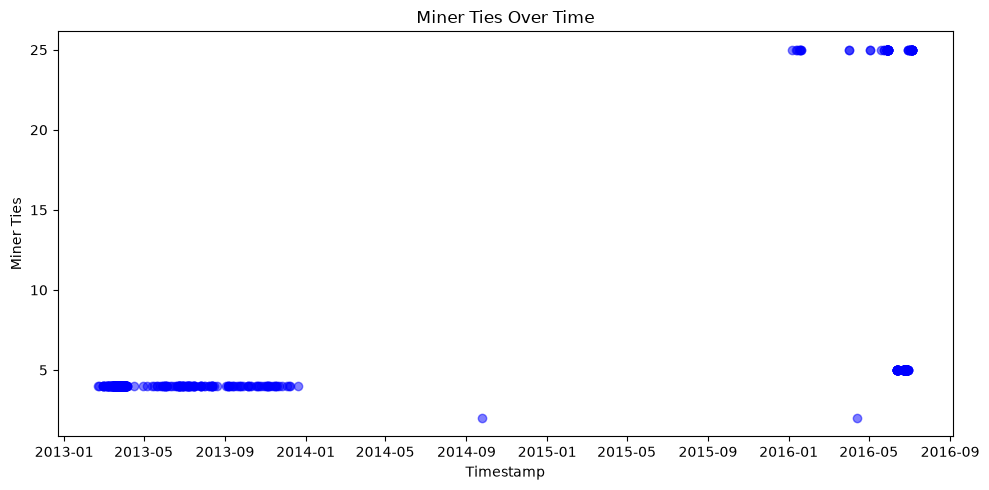

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(tied_df['block_timestamp'], tied_df['primary_miner_ties'], color='blue', alpha=0.5)
plt.title('Miner Ties Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Miner Ties')

plt.tight_layout()

plt.show()

In [26]:
tied_df['primary_miner_address'].value_counts()

primary_miner_address
1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo    319
1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq      2
1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno      1
1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ      1
1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C      1
                                     ... 
1PYhYMaU1KFVER5rV2uGHiQPiHk2sXFLJk      1
1PDQ6Xw2h2dtLkyeR4fE5ixxfbuCMDFpd       1
1o86w8w8sWY4iEVKK2St15vLLAczCb9Jr       1
1C52Cf3sKPjjY8Vjo9jo6bv6QrS5uTkAru      1
1U5p2x5PWJAiKf6754dXpbP3oLpKjbqnt       1
Name: count, Length: 168, dtype: int64

In [27]:
tied_df.groupby('primary_miner_ties')['primary_miner_address'].value_counts()

primary_miner_ties  primary_miner_address             
2                   1MXJ1UtN8EgWUGJpVXfRy9RxoHXaWUDDcz      1
                    1KVcqebRwgwRK6PMCrn34KoSRbm7gfXv8B      1
4                   1HorriBLeWypTH3YqEAn8J5LweNJHrZ7bo    319
5                   1PnkXDHD6KAiYAjdBSSxAaMeK3JkxD1Jqk      1
                    1P7jfbkVBbvcUZpfMxqaiXsTiTzg8puvjs      1
                                                         ... 
25                  1AJk3w9q7QEYyLNgzHCehfhpdpDaprx9Hr      1
                    1BtMnJtvyQfdxG6cEJDbRu2JNZLc1FMgyJ      1
                    1A73eLVnoW7zxF69Tdg2ESGteYbsg7pKtP      1
                    1BZAZpuhLPYmb4af68r5Kb81ji3ek8QuvB      1
                    1C52Cf3sKPjjY8Vjo9jo6bv6QrS5uTkAru      1
Name: count, Length: 168, dtype: int64

In [28]:
tied_df.groupby('primary_miner_ties')['primary_miner_address'].nunique()

primary_miner_ties
2       2
4       1
5     101
25     64
Name: primary_miner_address, dtype: int64

In [29]:
tied_df[tied_df['primary_miner_ties'] == 25]['primary_miner_address'].value_counts()

primary_miner_address
1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq    2
1DeL5jUwcQPBBSxxtgftuH8d57F4JgaSno    1
1DmRCSTeL8utyMMyZ6oWLju61wsbgy7UwZ    1
1Dhxq3BYG2e9wKxhhrsbVDwapNe1myBA1C    1
1D54769F3yPqCd7DpENvkYbSM3Ao726V1S    1
                                     ..
1B1azwjowZSe2AGcJvdZN9PUUTzJFrE33q    1
1CgShK16HLxYUABHTaKRu4TKHvqf9VE2Nt    1
1CEwuqSwwUvEYnR1YSjGiijfJTzHqXyq3p    1
1CaPM23KFrAFvvTKc61xq59LGptXMw3RK3    1
1C52Cf3sKPjjY8Vjo9jo6bv6QrS5uTkAru    1
Name: count, Length: 64, dtype: int64

In [30]:
tied_df[tied_df['primary_miner_address'] == '1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq']

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
502884,413851,2016-05-29 01:30:14+00:00,[{'address': '1BfS4N7kELa44jgFumZCqhe6WDb2cC8K...,[{'address': '1BfS4N7kELa44jgFumZCqhe6WDb2cC8K...,26,"(1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq, 25)",1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq,25
506420,413852,2016-05-29 01:37:12+00:00,[{'address': '1BfS4N7kELa44jgFumZCqhe6WDb2cC8K...,[{'address': '1BfS4N7kELa44jgFumZCqhe6WDb2cC8K...,26,"(1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq, 25)",1BfS4N7kELa44jgFumZCqhe6WDb2cC8KLq,25


# Miner Address Analysis

In [31]:
coinbase_df['primary_miner_address'].value_counts()

primary_miner_address
1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY    81237
18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX    34093
1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE    27261
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer    26204
1CjPR7Z5ZSyWk6WtXvSFgkptmpoi4UM9BC    23083
                                      ...  
1B5yjdjyQjQtR4NWMcBMSDtY3QVVCkcobQ        1
146KjiVc31gsNPJqbnXqbdNnQnPnfvmHHf        1
1PBhz4JgzCda6p3uq9Z9XdHM7pBf4xjHjz        1
13ySDJMkEJM6PTm4vRJbzgVJNHBvd2hq7X        1
1U5p2x5PWJAiKf6754dXpbP3oLpKjbqnt         1
Name: count, Length: 197095, dtype: int64

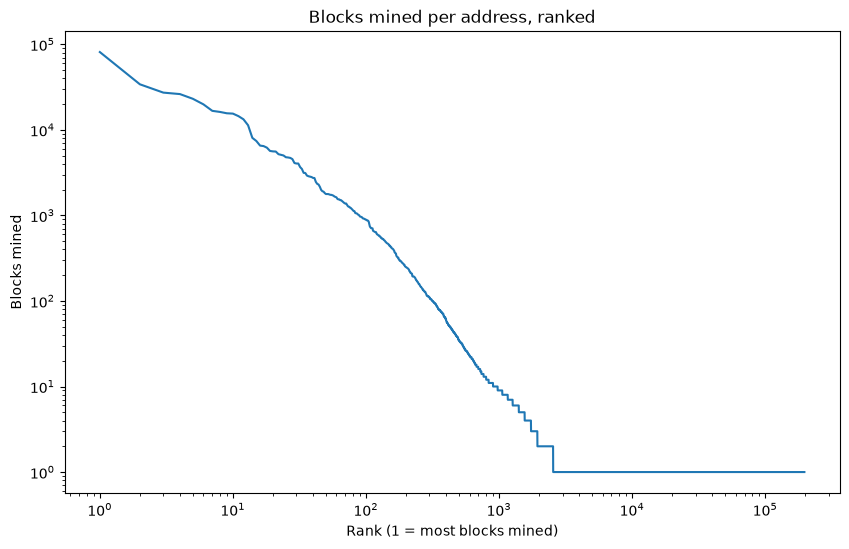

In [32]:
import matplotlib.pyplot as plt

miner_block_counts = coinbase_df['primary_miner_address'].value_counts()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(miner_block_counts) + 1), miner_block_counts.values)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank (1 = most blocks mined)')
plt.ylabel('Blocks mined')
plt.title('Blocks mined per address, ranked')
plt.show()

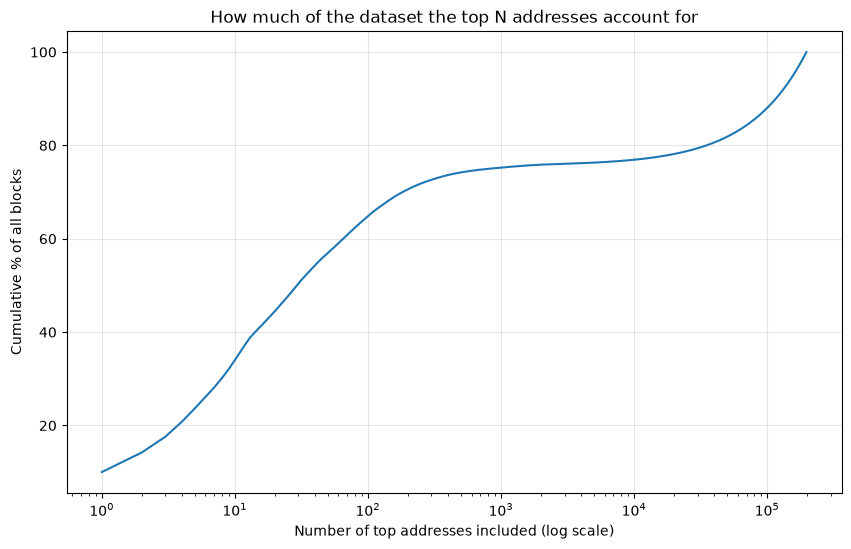

In [33]:
cumulative_blocks = miner_block_counts.cumsum()
cumulative_share = cumulative_blocks / miner_block_counts.sum() * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(miner_block_counts) + 1), cumulative_share.values)
plt.xscale('log')
plt.xlabel('Number of top addresses included (log scale)')
plt.ylabel('Cumulative % of all blocks')
plt.title('How much of the dataset the top N addresses account for')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Miners with only 1 block mined
(miner_block_counts == 1).sum()

np.int64(194548)

In [35]:
# Block counts at specific ranks
# index starts at 0
print(miner_block_counts.iloc[99])     # rank 100th  miner
print(miner_block_counts.iloc[499])    # rank 500th  miner
print(miner_block_counts.iloc[999])    # rank 1000th miner
print(miner_block_counts.iloc[1999])   # rank 2000th miner

print(miner_block_counts.iloc[[99, 499, 999, 1999]])

888
35
9
2
primary_miner_address
1BX5YoLwvqzvVwSrdD4dC32vbouHQn2tuF    888
126RKkWorhNMn825A5cVMJCKg2PpCNbPpw     35
1JUzcNDxGr1nadECsKTYE79zQPV7nkkS1x      9
1DDKms8pobe9Kxho1QKeHhFmt9cGHZUTPJ      2
Name: count, dtype: int64


In [40]:
# How many addresses have more than 2, 5, 10, 50 blocks
print(f"miners with >= 2 blocks : {(miner_block_counts >= 2).sum()}")
print(f"miners with >= 5 blocks : {(miner_block_counts >= 5).sum()}")
print(f"miners with >= 10 blocks: {(miner_block_counts >= 10).sum()}")
print(f"miners with >= 20 blocks: {(miner_block_counts >= 20).sum()}")
print(f"miners with >= 30 blocks: {(miner_block_counts >= 30).sum()}")
print(f"miners with >= 40 blocks: {(miner_block_counts >= 40).sum()}")
print(f"miners with >= 50 blocks: {(miner_block_counts >= 50).sum()}")
print(f"miners with >= 100 blocks: {(miner_block_counts >= 100).sum()}")

miners with >= 2 blocks : 2547
miners with >= 5 blocks : 1556
miners with >= 10 blocks: 975
miners with >= 20 blocks: 647
miners with >= 30 blocks: 537
miners with >= 40 blocks: 474
miners with >= 50 blocks: 430
miners with >= 100 blocks: 317


In [37]:
# how many blocks are mined by miners with >= 2 blocks
miner_block_counts[miner_block_counts >= 2].sum()

np.int64(616359)

In [41]:
total_blocks = miner_block_counts.sum()
print(total_blocks)

for threshold in [2, 5, 10, 20, 30, 40, 50, 100]:
    blocks_covered = miner_block_counts[miner_block_counts >= threshold].sum()
    pct = blocks_covered / total_blocks * 100
    print(f"miners with >= {threshold:>2} blocks: {blocks_covered:>7} blocks ({pct:.2f}% of dataset)")

810907
miners with >=  2 blocks:  616359 blocks (76.01% of dataset)
miners with >=  5 blocks:  613814 blocks (75.69% of dataset)
miners with >= 10 blocks:  609922 blocks (75.21% of dataset)
miners with >= 20 blocks:  605679 blocks (74.69% of dataset)
miners with >= 30 blocks:  603046 blocks (74.37% of dataset)
miners with >= 40 blocks:  600885 blocks (74.10% of dataset)
miners with >= 50 blocks:  598936 blocks (73.86% of dataset)
miners with >= 100 blocks:  590786 blocks (72.85% of dataset)
